# OnboardAI — Capstone Evidence Notebook

**Declared track:** Track A — Supervisor + Workers  
**Named workflow:** Orchestrator-Worker

Run this notebook from a fresh kernel, top-to-bottom, with synthetic data only. Save the real outputs before submission. Offline output is not valid evidence of LLM routing.

## 0. Team and Programme Information

- **Project:** OnboardAI — Human-Supervised HR Onboarding Orchestrator
- **Declared track:** Track A — Supervisor + Workers
- **Training programme:** Building AI Agent Systems
- **Cohort dates:** 9 August 2026 — 13 August 2026
- **Instructor:** Mohammad Albeladi

### Team Members

The project was completed collaboratively by all team members, with no formal individual role assignment.

- Aleen Alfawzan
- Fadwa Nasser Aldukhi
- Reem Almehize
- Noura Almuqbil
- Moudi Alhomoud

- **SDAIA Academy GitHub:** https://github.com/SDAIAAcademy

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd "/content/drive/MyDrive/OnboardAI_Capstone"

/content/drive/MyDrive/OnboardAI_Capstone


In [ ]:
!ls

ARCHITECTURE.md			   README.md	       src
data				   requirements.txt    SUBMISSION_INFO.md
notebooks			   RUBRIC_EVIDENCE.md  SUBMISSION_INFO.md.gdoc
OnboardAI_Capstone_Evidence.ipynb  runtime	       tests
pyproject.toml			   SECURITY.md	       VERIFICATION.md


In [ ]:
%pip install -e ".[dev]"

Obtaining file:///content/drive/MyDrive/OnboardAI_Capstone
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for onboardai (pyproject.toml) ... done
  Created wheel for onboardai: filename=onboardai-0.1.0-0.editable-py3-none-any.whl size=5349 sha256=dc884e7ea426b9cf51dd5d7e3c743a45ed13a9b9be8865d330537731692e9222
  Stored in directory: /tmp/pip-ephem-wheel-cache-ut366l67/wheels/e3/12/72/5d03690c2abced3ad5cc0d379d8f09187486f5a7445a4ba9cd
Successfully built onboardai
  Attempting uninstall: onboardai
    Found existing installation: onboardai 0.1.0
    Uninstalling onboardai-0.1.0:
      Successfully uninstalled onboardai-0.1.0


In [ ]:
!pip show onboardai

Name: onboardai
Version: 0.1.0
Summary: Human-supervised multi-agent HR onboarding capstone built with LangChain and LangGraph
Home-page: 
Author: 
Author-email: 
License: 
Location: /usr/local/lib/python3.12/dist-packages
Editable project location: /content/drive/MyDrive/OnboardAI_Capstone
Requires: email-validator, jinja2, langchain, langchain-groq, langchain-huggingface, langchain-text-splitters, langgraph, langgraph-checkpoint-sqlite, langsmith, pydantic, python-dotenv, sentence-transformers
Required-by: 


In [ ]:
import os
from google.colab import userdata

# Load API keys from Colab Secrets
os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")
os.environ["LANGSMITH_API_KEY"] = userdata.get("LANGSMITH_API_KEY")

# LangSmith configuration
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGSMITH_PROJECT"] = "onboardai-capstone"

# Embeddings
os.environ["ONBOARDAI_EMBEDDINGS"] = "huggingface"

# Verify
assert os.getenv("GROQ_API_KEY"), "Set GROQ_API_KEY through Colab Secrets"
assert os.getenv("LANGSMITH_API_KEY"), "Set LANGSMITH_API_KEY through Colab Secrets"

print("✅ GROQ_API_KEY loaded")
print("✅ LANGSMITH_API_KEY loaded")
print("✅ Configuration complete")

✅ GROQ_API_KEY loaded
✅ LANGSMITH_API_KEY loaded
✅ Configuration complete


## 1. RAG pipeline evidence
This must report `huggingface`, indexed documents/chunks, and cited retrieved passages.

In [ ]:
from onboardai.demo import run_rag_evidence
run_rag_evidence(live_embeddings=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

{
  "query": "Which training and access are required for a Software Engineer who lacks Docker?",
  "indexed_documents": 4,
  "indexed_chunks": 13,
  "retrieved": [
    {
      "source": "role_competencies.csv#chunk-004",
      "category": "role",
      "excerpt": "role: Software Engineer department: Engineering required_skills: Python; Git; APIs; testing; Docker fundamentals standard_access: email; identity; GitHub; issue tracker privileged_access: VPN"
    },
    {
      "source": "training_catalog.csv#chunk-009",
      "category": "training",
      "excerpt": "course_id: ENG-201 title: Container Fundamentals skills: Docker; containers; image security format: online duration: 6 hours mandatory_for: Software Engineer"
    },
    {
      "source": "policy_information_security.md#chunk-000",
      "category": "policy",
      "excerpt": "# Information Security and Access Policy (Synthetic) All employees receive corporate email, identity management, and security-awareness training. Access 

### RAG Architecture Choice

OnboardAI uses a **Hybrid RAG** architecture because the HR onboarding problem contains both mandatory policy knowledge and context-dependent information needs.

A **2-Step RAG** approach would retrieve documents first and then pass the retrieved context to the LLM. This would provide predictable retrieval, but it would be less flexible when a specialist needs additional context-specific searches.

A fully **Agentic RAG** approach would allow the LLM to decide when and how to retrieve information. However, relying entirely on optional agentic retrieval is unsafe for mandatory HR policies because the model could potentially skip required evidence.

Therefore, OnboardAI uses a **Hybrid RAG** design:

- **Fixed retrieval:** mandatory role, training, and policy evidence is retrieved and injected into the specialist context for every worker.
- **Agentic retrieval:** specialist agents also have access to an approved knowledge-search tool and can perform additional contextual searches when needed.
- **Citations:** retrieved evidence includes the source and excerpt so that material recommendations can be traced back to the approved knowledge base.

This architecture fits the project because mandatory HR and security requirements must always be considered, while onboarding recommendations may also require additional context-specific retrieval.

## 2. Live structured routing evidence
The two requests must show different typed destinations and reasons.

In [ ]:
from onboardai.demo import run_routing_evidence
run_routing_evidence()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

{
  "request": "Create a cited 30/60/90-day training plan for this employee.",
  "destination": "training",
  "reason": "The user has requested a cited 30/60/90-day training plan for the employee, and the training worker is the only requested and unfinished worker available to fulfill this request.",
  "confidence": "high"
}
{
  "request": "Prepare the least-privilege workspace access request.",
  "destination": "it_provisioning",
  "reason": "The user has requested the preparation of a least-privilege workspace access request for a Financial Analyst in the Finance department, and it_provisioning is the only requested and unfinished worker, which is responsible for role-based access planning and risk flags.",
  "confidence": "high"
}


## 3. Full workflow: RetryPolicy, pause, and resume
Capture attempt #1 → #2, the approval interrupt, and completed outcome.

In [ ]:
from onboardai.demo import run_full
run_full(live=True, case_index=0, simulate_failure=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

MODE: LIVE LLM
THREAD: CASE-ENG-001-91d8251e
[supervisor] destination=training confidence=high reason=The user request is to complete post-hire onboarding and personalize the learning plan for a Software Engineer in the Engineering department. The training worker is the most relevant to this request as it provides skill-gap analysis and cited training recommendations, which is essential for personalizing the learning plan.
[supervisor] destination=hr_documents confidence=high reason=The training worker has completed the skill-gap analysis and provided cited training recommendations. Now, to complete post-hire onboarding and personalize the learning plan for the Software Engineer in the Engineering department, the hr_documents worker should be selected to review policies and draft onboarding communications.
[supervisor] destination=it_provisioning confidence=high reason=The user has requested to complete post-hire onboarding and personalize the learning plan for a Software Engineer in t

## 3.1 Functional API and RetryPolicy Evidence

OnboardAI uses LangGraph's Functional API with `@entrypoint` for the
durable workflow and `@task` for individual workflow operations.

The workflow also uses `RetryPolicy` for the IT ticket creation task.
In the live demonstration, the first attempt intentionally fails with a
simulated transient network error, and the task automatically retries
and succeeds on the second attempt.

The workflow uses `interrupt()` to pause for missing information and
human approval, and `Command(resume=...)` to continue execution after
the required input or approval is provided.

In [ ]:
from onboardai.demo import run_full

run_full(
    live=True,
    case_index=0,
    simulate_failure=True
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

MODE: LIVE LLM
THREAD: CASE-ENG-001-a782c7ba
[supervisor] destination=training confidence=high reason=The user request is to complete post-hire onboarding and personalize the learning plan for a Software Engineer in the Engineering department. The training worker is the most relevant to this request as it provides skill-gap analysis and cited training recommendations, which is essential for personalizing the learning plan.
[supervisor] destination=hr_documents confidence=high reason=The training worker has completed the skill-gap analysis and provided cited training recommendations. Now, to complete post-hire onboarding and personalize the learning plan for the Software Engineer in the Engineering department, the hr_documents worker should be selected to review policies and draft onboarding communications.
[supervisor] destination=it_provisioning confidence=high reason=The user has requested to complete post-hire onboarding and personalize the learning plan for a Software Engineer in t

In [ ]:
from pathlib import Path

workflow_code = Path("src/onboardai/workflow.py").read_text()

print("Functional API Evidence")
print("@entrypoint:", "✅" if "@entrypoint" in workflow_code else "❌")
print("@task:", "✅" if "@task" in workflow_code else "❌")

print("\nRetry Evidence")
print("RetryPolicy:", "✅" if "RetryPolicy" in workflow_code else "❌")
print("TransientITError:", "✅" if "TransientITError" in workflow_code else "❌")

print("\nInterrupt / Resume Evidence")
print("interrupt():", "✅" if "interrupt(" in workflow_code else "❌")
print("Command(resume=...):", "✅" if "Command(resume=" in workflow_code else "❌")

Functional API Evidence
@entrypoint: ✅
@task: ✅

Retry Evidence
RetryPolicy: ✅
TransientITError: ✅

Interrupt / Resume Evidence
interrupt(): ✅
Command(resume=...): ❌


## 4. Missing-information interrupt
Case 2 has no start date. The run must pause for that value, resume, pause for approval, and complete.

In [ ]:
run_full(live=True, case_index=2, simulate_failure=False)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

MODE: LIVE LLM
THREAD: CASE-HR-003-7dffc12d

PAUSED FOR REQUIRED INFORMATION
{
  "type": "missing_information",
  "case_id": "CASE-HR-003",
  "field": "start_date",
  "message": "A start date is required. Supply {'start_date': 'YYYY-MM-DD'}."
}
[supervisor] destination=hr_documents confidence=high reason=The user has requested HR onboarding preparation, and hr_documents is one of the requested workers that can provide policy review and draft onboarding communications, which is a necessary step in the onboarding process.
[supervisor] destination=training confidence=high reason=The user has requested HR onboarding preparation and the 'hr_documents' worker is already complete. The 'training' worker is still unfinished and is required for the onboarding process to identify any skill gaps and provide training recommendations.
[supervisor] destination=it_provisioning confidence=high reason=The user has requested HR onboarding preparation and all requested workers except it_provisioning have 

## 5. Cross-thread Store evidence

In [ ]:
from onboardai.demo import run_memory_evidence

run_memory_evidence()

{
  "thread_A": "thread-A",
  "written_fact": {
    "preferred_language": "Arabic",
    "training_format": "online"
  }
}
{
  "thread_B": "thread-B",
  "same_employee": "EMP-CROSS-THREAD",
  "recalled_from_separate_Store": {
    "preferred_language": "Arabic",
    "training_format": "online"
  },
  "conversation_history_inherited": false
}


## 6. LangSmith Observability

LangSmith tracing was successfully enabled for the `onboardai-capstone` project.

In [ ]:
import os

os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGSMITH_PROJECT"] = "onboardai-capstone"

print("LANGSMITH_TRACING =", os.getenv("LANGSMITH_TRACING"))
print("LANGCHAIN_TRACING_V2 =", os.getenv("LANGCHAIN_TRACING_V2"))
print("LANGSMITH_PROJECT =", os.getenv("LANGSMITH_PROJECT"))

LANGSMITH_TRACING = true
LANGCHAIN_TRACING_V2 = true
LANGSMITH_PROJECT = onboardai-capstone


## LangSmith Observability Evidence

LangSmith tracing was successfully enabled for the `onboardai-capstone` project, and the capstone workflow produced a recorded trace.

### Observed trace statistics

- **Project:** `onboardai-capstone`
- **Turns:** 2
- **First start:** 08/11/2026, 11:14:07 PM GMT+3
- **Last end:** 08/11/2026, 11:14:14 PM GMT+3
- **P50 latency:** 0.06 seconds
- **P99 latency:** 0.06 seconds
- **Input tokens:** approximately 5.4K
- **Output tokens:** approximately 1.1K
- **Total tokens:** approximately 6.5K
- **Reported total cost:** $0.0040

### Reliability behavior observed during the run

The workflow also demonstrated the retry behavior of the IT ticket creation task. The first attempt produced a simulated transient network error, after which the task was retried and succeeded on the second attempt.

This trace/run evidence confirms that LangSmith was capturing the workflow execution and that the retry mechanism was exercised during an actual capstone run.

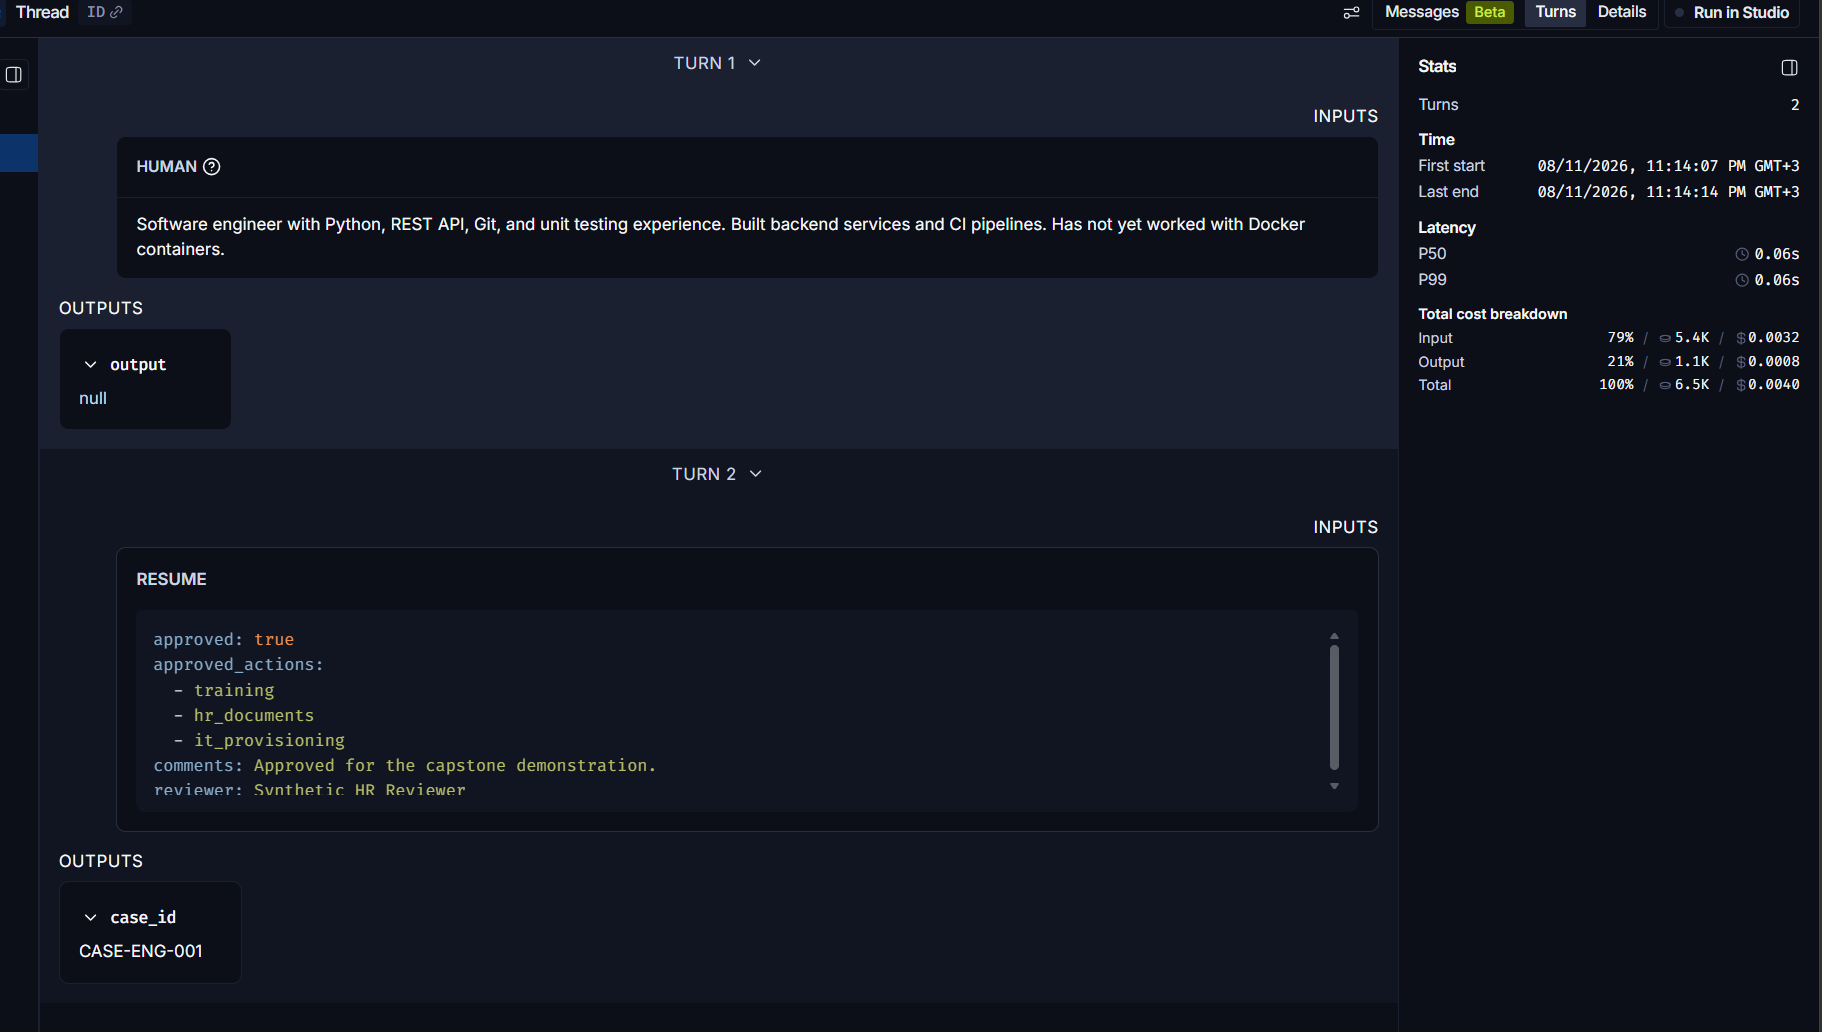

**LangSmith trace evidence:** The screenshot shows the recorded `onboardai-capstone` trace, including two turns, timing information, token usage, and reported cost.


## 7. Workflow Pattern — Orchestrator-Worker

**Pattern used: Orchestrator-Worker**

OnboardAI uses the **Orchestrator-Worker** workflow pattern. A supervisor acts as the orchestrator and uses the LLM to determine which specialist worker should handle each part of the onboarding request. The available workers are Training, HR Documents, and IT Provisioning.

The orchestrator evaluates the remaining work after each worker completes and selects the next appropriate specialist. The workflow continues until all requested workers are complete.

Orchestrator-Worker fits this project because HR onboarding contains multiple specialized domains. The supervisor provides centralized coordination while each worker remains responsible for its specific domain.